# Step 7: Optimizer Comparison Study

Train identical 1D ResNet with 5 optimizers under identical conditions.
Every result is grounded in the specific Adam paper section that predicts it.

Optimizers: SGD | SGD+Momentum | AdaGrad | RMSProp | Adam

Results: training loss curves, val macro F1 curves, per-class F1 comparison table

In [1]:
import sys, os
from pathlib import Path
_r = Path.cwd()
while not (_r / 'src').is_dir():
    _r = _r.parent
os.chdir(_r)
if str(_r) not in sys.path:
    sys.path.insert(0, str(_r))

from src.optimizers.comparison import run_optimizer_comparison
from src.optimizers.convergence_plots import (
    plot_training_loss_curves,
    plot_val_f1_curves,
    plot_final_macro_f1_comparison,
    plot_convergence_speed,
)
from src.utils.device import get_device

In [2]:
from src.data.loader import load_mitbih
from src.data.preprocessor import preprocess
from src.data.dataset import build_dataloaders

X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_mitbih()
splits = preprocess(X_train_raw, y_train_raw, X_test_raw, y_test_raw, val_fraction=0.15)
train_loader, val_loader, test_loader = build_dataloaders(splits, batch_size=128)
print(f'Data ready — train: {splits["X_train"].shape}, val: {splits["X_val"].shape}')

Data ready — train: (307870, 187, 1), val: (13134, 187, 1)


In [3]:
device = get_device()
from src.training.focal_loss import compute_class_frequencies
pre_smote_freqs = compute_class_frequencies(y_train_raw)
histories = run_optimizer_comparison(
    train_loader, val_loader, device,
    random_seed=42,
    pre_smote_class_frequencies=pre_smote_freqs,
)

Using GPU: NVIDIA GeForce RTX 4070 Laptop GPU

Training with optimizer: SGD


Epoch   1/100 | loss 0.0839/0.0384 | f1 0.6464/0.3408 | 18.5s


Epoch   2/100 | loss 0.0144/0.0229 | f1 0.7777/0.4922 | 17.8s


Epoch   3/100 | loss 0.0075/0.0179 | f1 0.8774/0.5851 | 17.8s


Epoch   4/100 | loss 0.0047/0.0169 | f1 0.9228/0.6378 | 17.9s


...

Epoch  96/100 | loss 0.0001/0.0214 | f1 0.9989/0.8992 | 18.3s


Epoch  97/100 | loss 0.0001/0.0228 | f1 0.9989/0.9010 | 18.3s


Epoch  98/100 | loss 0.0001/0.0231 | f1 0.9990/0.9026 | 18.3s


Epoch  99/100 | loss 0.0001/0.0233 | f1 0.9991/0.9075 | 18.3s


Epoch 100/100 | loss 0.0001/0.0217 | f1 0.9990/0.8955 | 18.3s
Saved history: results/logs/adam_history.json


In [4]:
# Recovery cell: reload histories from saved JSON files if training was interrupted
# or if this cell is run in a fresh kernel after training has already completed.
from src.utils.io import load_artifact
from pathlib import Path

if "histories" not in dir() or not histories:
    histories = {}
    for p in sorted(Path("results/logs").glob("*_history.json")):
        name = p.stem.replace("_history", "")
        histories[name] = load_artifact(str(p))
    if histories:
        print(f"Loaded histories from disk: {list(histories.keys())}")
    else:
        print("No saved histories found. Run the training cell first.")
else:
    print(f"Using in-memory histories: {list(histories.keys())}")

Using in-memory histories: ['sgd', 'sgd_momentum', 'adagrad', 'rmsprop', 'adam']


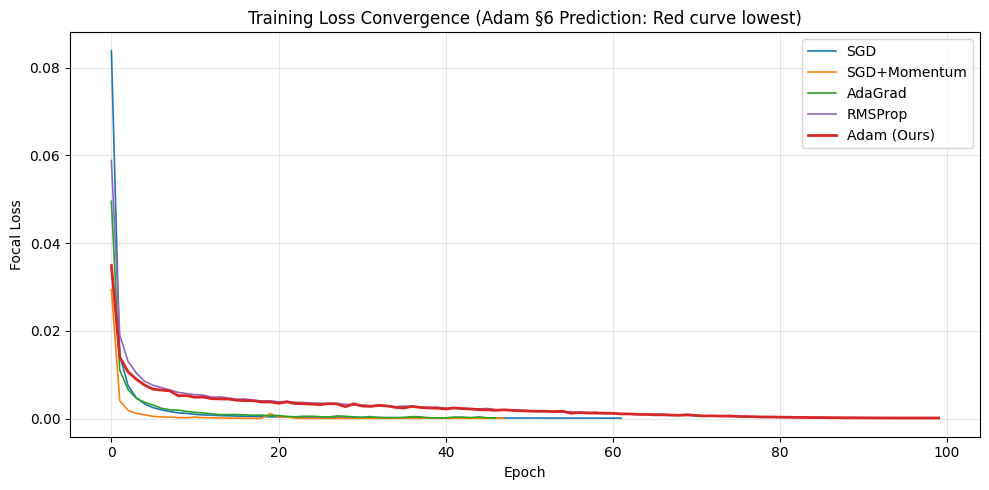

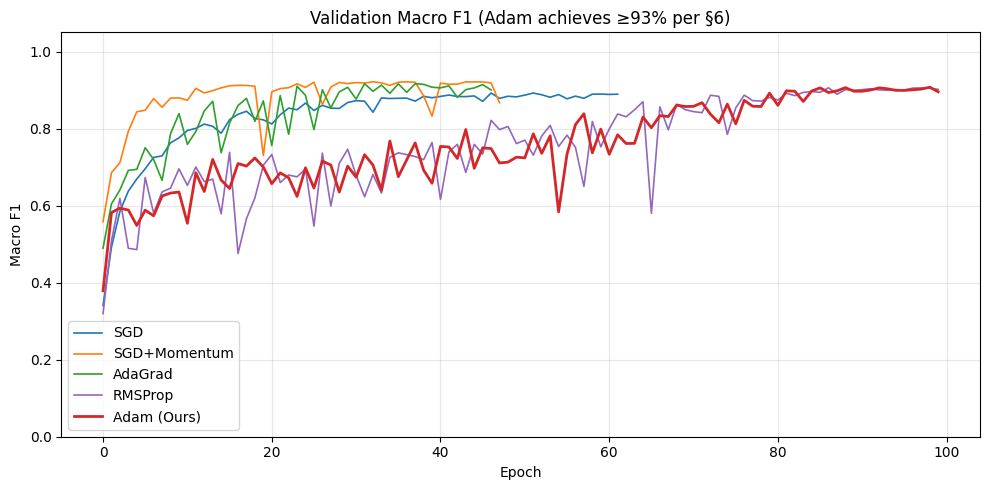

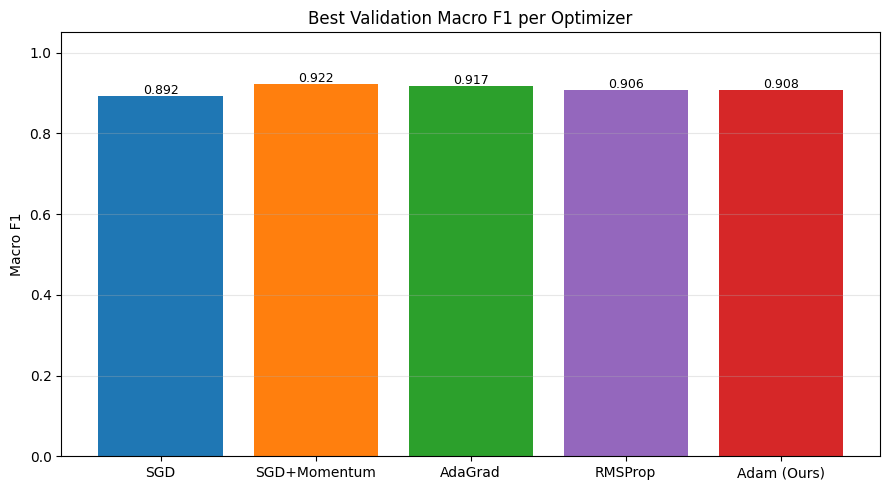


Optimizer               Best F1    Epochs to F1≥0.90
------------------------------------------------------
SGD                      0.8924                never
SGD+Momentum             0.9217                   12
AdaGrad                  0.9168                   24
RMSProp                  0.9061                   87
Adam (Ours)              0.9075                   86



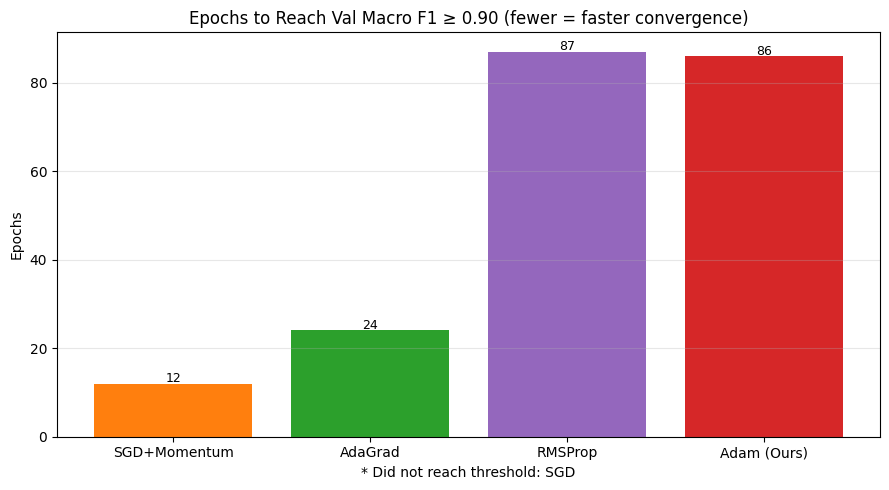

In [5]:
plot_training_loss_curves(histories, save_path='results/plots/training_curves/loss_all_optimizers.png')
plot_val_f1_curves(histories, save_path='results/plots/training_curves/val_f1_all_optimizers.png')
plot_final_macro_f1_comparison(histories, save_path='results/plots/training_curves/best_macro_f1.png')
plot_convergence_speed(histories, threshold=0.90, save_path='results/plots/training_curves/convergence_speed.png')